# 🧠 Phase 3: Deep Learning
**Architecture:** 5-Layer Deep Neural Network  
---

## 1️⃣ Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')
print(f'✅ TensorFlow version: {tf.__version__}')

✅ TensorFlow version: 2.18.0


## 2️⃣ Load & Preprocess Data

In [2]:
df = pd.read_csv('../data/online_shoppers_intention.csv')
df_p = df.copy()
le = LabelEncoder()
df_p['Month'] = le.fit_transform(df_p['Month'])
df_p['VisitorType'] = le.fit_transform(df_p['VisitorType'])
df_p['Weekend'] = df_p['Weekend'].astype(int)
df_p['Revenue'] = df_p['Revenue'].astype(int)
X = df_p.drop('Revenue', axis=1)
y = df_p['Revenue']
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.20, random_state=42, stratify=y_res)
X_train_np = np.array(X_train)
X_test_np = np.array(X_test)
y_train_np = np.array(y_train)
y_test_np = np.array(y_test)
print(f'✅ Data ready: Train={X_train_np.shape} | Test={X_test_np.shape}')

✅ Data ready: Train=(16675, 17) | Test=(4169, 17)


## 3️⃣ Build Model Architecture

In [3]:
def build_model(input_dim):
    inputs = Input(shape=(input_dim,))
    x = Dense(512, activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    features = Dense(32, activation='relu', name='feature_layer')(x)
    output = Dense(1, activation='sigmoid', name='output')(features)
    return Model(inputs=inputs, outputs=output)

model = build_model(X_train_np.shape[1])
model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 17)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 187,649 (733.00 KB)

 Trainable params: 185,729 (725.50 KB)

 Non-trainable params: 1,920 (7.50 KB)

## 4️⃣ Train Model

In [4]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, verbose=1)
]
history = model.fit(X_train_np, y_train_np, epochs=300, batch_size=32,
                    validation_split=0.2, callbacks=callbacks, verbose=1)

Epoch 1/300
417/417 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.7306 - loss: 0.5347 - val_accuracy: 0.8393 - val_loss: 0.3841 - learning_rate: 0.0010
Epoch 2/300
417/417 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8364 - loss: 0.3927 - val_accuracy: 0.8570 - val_loss: 0.3425 - learning_rate: 0.0010
Epoch 3/300
417/417 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8444 - loss: 0.3725 - val_accuracy: 0.8666 - val_loss: 0.3358 - learning_rate: 0.0010
Epoch 4/300
417/417 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8566 - loss: 0.3484 - val_accuracy: 0.8759 - val_loss: 0.3189 - learning_rate: 0.0010
Epoch 5/300
417/417 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8627 - loss: 0.3412 - val_accuracy: 0.8714 - val_loss: 0.3200 - learning_rate: 0.0010
Epoch 6/300
417/417 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8676 - loss: 0.3251 - val_accuracy: 0.8759 - val_loss: 0.3088 - learning_rate: 0.0010
Epoch 7/300
417/417 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8728 - 

## 5️⃣ Training History

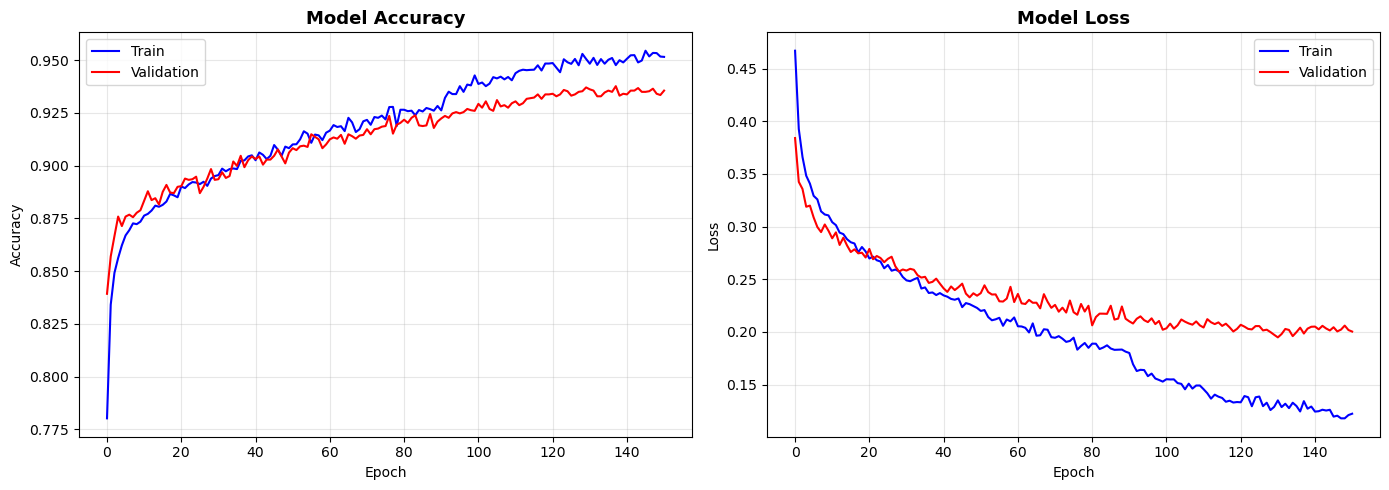

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'], label='Train', color='blue')
axes[0].plot(history.history['val_accuracy'], label='Validation', color='red')
axes[0].set_title('Model Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Train', color='blue')
axes[1].plot(history.history['val_loss'], label='Validation', color='red')
axes[1].set_title('Model Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/deep_learning_training.png', dpi=300, bbox_inches='tight')
plt.show()

## 6️⃣ Evaluate & Extract Features

In [6]:
y_prob = model.predict(X_test_np).flatten()
y_pred = (y_prob > 0.5).astype(int)
print(classification_report(y_test_np, y_pred, target_names=['No Purchase', 'Purchase']))
print(f'🎯 ROC AUC: {roc_auc_score(y_test_np, y_prob):.3f}')

feature_extractor = Model(inputs=model.input, outputs=model.get_layer('feature_layer').output)
deep_features_train = feature_extractor.predict(X_train_np, verbose=0)
deep_features_test = feature_extractor.predict(X_test_np, verbose=0)
np.save('../outputs/reports/deep_features_train.npy', deep_features_train)
np.save('../outputs/reports/deep_features_test.npy', deep_features_test)
np.save('../outputs/reports/y_train.npy', y_train_np)
np.save('../outputs/reports/y_test.npy', y_test_np)
print(f'✅ Deep Features saved! Shape: {deep_features_train.shape}')

131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
              precision    recall  f1-score   support

 No Purchase       0.95      0.89      0.92      2085
    Purchase       0.90      0.96      0.93      2084

    accuracy                           0.93      4169
   macro avg       0.93      0.93      0.93      4169
weighted avg       0.93      0.93      0.93      4169

🎯 ROC AUC: 0.972
✅ Deep Features saved! Shape: (16675, 32)
